# Customer Churn Analysis and High-Value Customer Segmentation

---

## Project Overview

### Overview
This project explores customer churn behaviour within a telecommunications company using Python, statistical modelling, and customer segmentation techniques. The analysis focuses on identifying the key drivers of churn, understanding customer retention patterns, and defining high-value customer profiles.

Using data preprocessing, feature engineering, exploratory data analysis, correlation analysis, and logistic regression modelling, the project transforms raw customer information into actionable business insights.

The final objective is to support data-driven retention strategies, customer segmentation, and revenue optimization.

---

## Business Objective

### Business Objective
The objective of this analysis is to:

- Identify the main factors influencing customer churn
- Quantify the impact of pricing, contracts, and customer engagement on churn probability
- Detect high-risk customer segments
- Define high-value customers based on revenue contribution and retention likelihood
- Support retention and upselling strategies using predictive analytics



## Data Loading and Initial Exploration

### Data Loading and Initial Exploration
The dataset was imported into Python using pandas and explored to understand its structure, variable types, and overall data quality.

Initial checks included:

- Reviewing data types and missing values
- Understanding customer demographics and service subscriptions
- Identifying categorical and numerical variables
- Assessing dataset dimensions and feature distribution

This step established the foundation for data cleaning and feature engineering.


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Cleaning

### Data Cleaning
Several preprocessing steps were performed to improve data quality and ensure consistency across categorical variables.

Key transformations included:

- Converting `TotalCharges` from object to numeric format
- Handling missing values created during conversion
- Standardising categorical values such as:
  - `No phone service` → `No`
  - `No internet service` → `No`
- Removing the `customerID` column, as it does not provide predictive value

These transformations simplified the dataset and improved model interpretability.

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [4]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service','No' )
print(df['MultipleLines'].unique())

['No' 'Yes']


In [5]:
df['OnlineSecurity'] =df['OnlineSecurity'].replace('No internet service', 'No')
print(df['OnlineSecurity'].unique())

['No' 'Yes']


In [6]:
df['OnlineBackup'] =df['OnlineBackup'].replace('No internet service', 'No')
print(df['OnlineBackup'].unique())

['Yes' 'No']


In [7]:
df['DeviceProtection'] = df['DeviceProtection'].replace('No internet service', 'No')
print(df['DeviceProtection'].unique())

['No' 'Yes']


In [8]:
df['TechSupport']= df['TechSupport'].replace('No internet service', 'No' )
print(df['TechSupport'].unique())

['No' 'Yes']


In [9]:
df['StreamingTV'] = df['StreamingTV'].replace('No internet service', 'No')
print(df['StreamingTV'].unique())

['No' 'Yes']


In [10]:
df['StreamingMovies'] = df['StreamingMovies'].replace('No internet service', 'No')
print(df['StreamingMovies'].unique())

['No' 'Yes']


In [11]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [12]:
df=df.drop(columns=['customerID'])

## Dummy Variable Transformation & Feature Engineering

### Dummy Variable Transformation
Categorical variables were converted into dummy variables using one-hot encoding.

This transformation allowed the categorical features to be incorporated into the logistic regression model.

The `drop_first=True` option was used to:

- Reduce redundancy
- Avoid the dummy variable trap
- Improve model stability and interpretation

---

### Feature Engineering
To better capture customer engagement, a new variable called `num_services` was created.

This variable measures the total number of subscribed services per customer, including:

- Online Security
- Online Backup
- Device Protection
- Tech Support
- Streaming TV
- Streaming Movies

The purpose of this feature was to quantify customer integration into the company ecosystem.

Customers with more services are expected to exhibit:

- Higher engagement
- Greater switching costs
- Lower churn probability

In [13]:
#Dummy Variable Transformation

df= pd.get_dummies(df, drop_first=True, dtype=int)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7043 non-null   int64  
 5   Partner_Yes                            7043 non-null   int64  
 6   Dependents_Yes                         7043 non-null   int64  
 7   PhoneService_Yes                       7043 non-null   int64  
 8   MultipleLines_Yes                      7043 non-null   int64  
 9   InternetService_Fiber optic            7043 non-null   int64  
 10  InternetService_No                     7043 non-null   int64  
 11  Onli

In [14]:
#Feature Engineering

df['num_services'] = (
    df[['OnlineSecurity_Yes',
        'OnlineBackup_Yes',
        'DeviceProtection_Yes',
        'TechSupport_Yes',
        'StreamingTV_Yes',
        'StreamingMovies_Yes',
       'PhoneService_Yes',
       'InternetService_No',
       'InternetService_Fiber optic']]
    .sum(axis=1)
)
df= df.drop(columns=['OnlineSecurity_Yes',
        'OnlineBackup_Yes',
        'DeviceProtection_Yes',
        'TechSupport_Yes',
        'StreamingTV_Yes',
        'StreamingMovies_Yes',
        'PhoneService_Yes',
        'InternetService_No',
        'InternetService_Fiber optic'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7043 non-null   int64  
 5   Partner_Yes                            7043 non-null   int64  
 6   Dependents_Yes                         7043 non-null   int64  
 7   MultipleLines_Yes                      7043 non-null   int64  
 8   Contract_One year                      7043 non-null   int64  
 9   Contract_Two year                      7043 non-null   int64  
 10  PaperlessBilling_Yes                   7043 non-null   int64  
 11  Paym

## Correlation Heatmap Analysis

### Correlation Heatmap Analysis
A correlation heatmap was created to analyse relationships between customer features and churn behaviour.


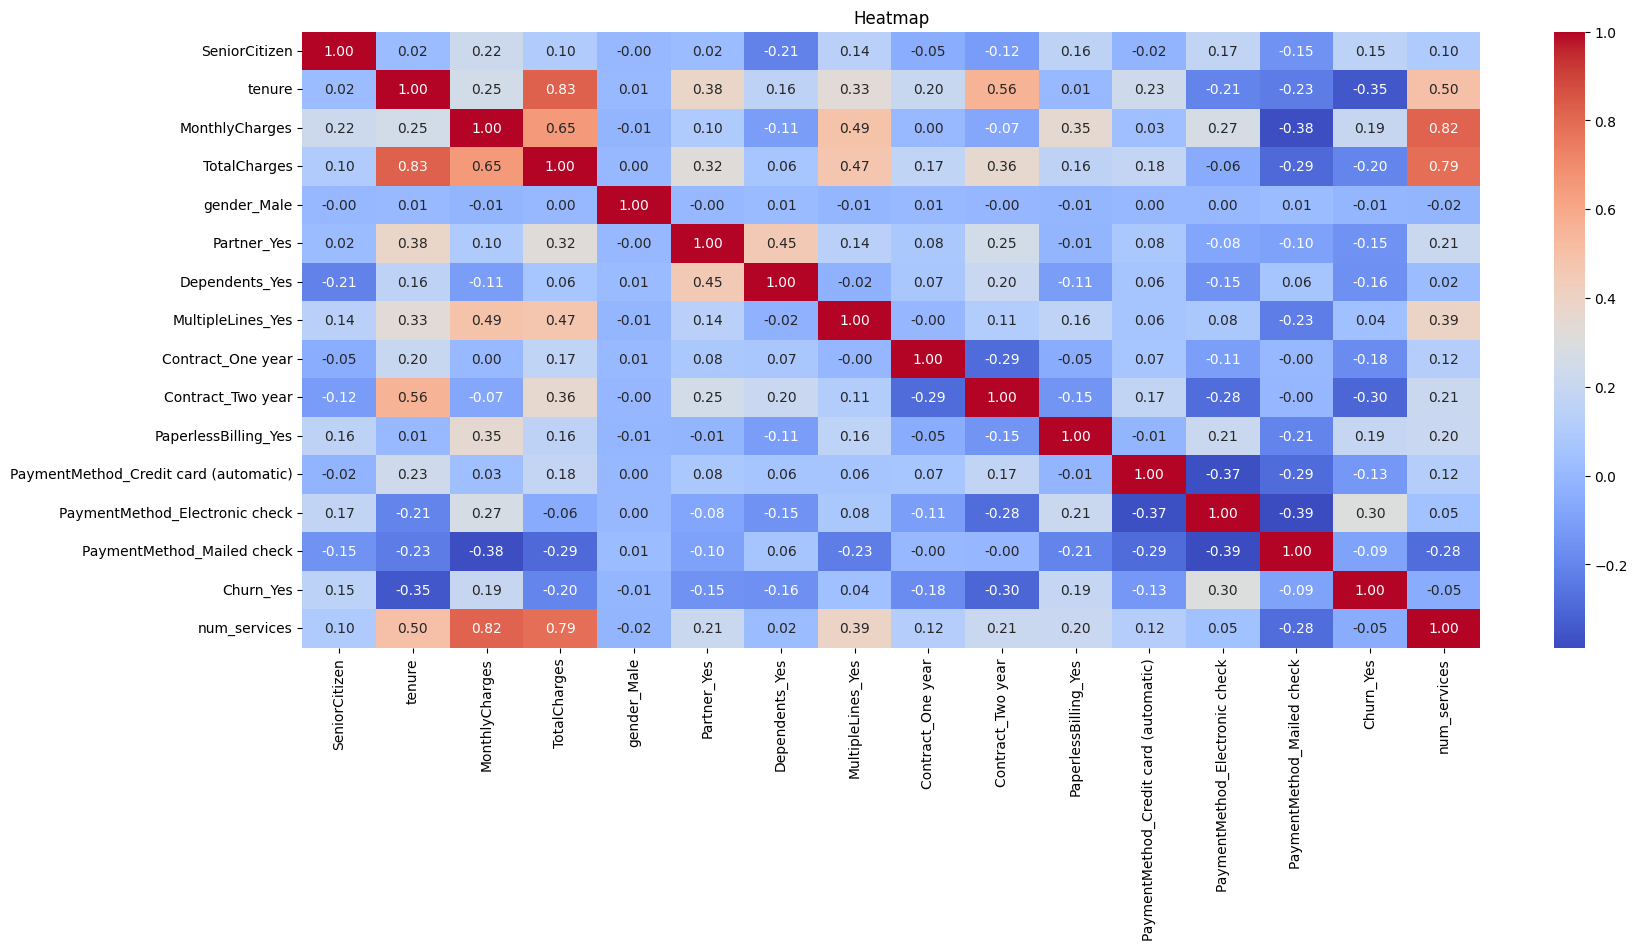

In [15]:
# Heatmap
corr = df.corr()
plt.figure(figsize=(19,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap')
plt.show()

### Key Findings

- `tenure` showed a strong negative correlation with churn, indicating that long-term customers are less likely to leave.
- `Contract_Two year` displayed one of the strongest negative relationships with churn, highlighting the importance of long-term commitment.
- `MonthlyCharges` was positively correlated with churn, suggesting increased price sensitivity among customers.
- `num_services` was negatively correlated with churn, showing that highly engaged customers are more likely to remain loyal.
- `InternetService_Fiber optic` and `PaymentMethod_Electronic check` displayed positive relationships with churn, identifying potentially higher-risk customer segments.

The heatmap also revealed strong relationships between variables such as:

- `tenure` and `TotalCharges`
- `MonthlyCharges` and `num_services`

These insights guided feature selection and model optimization.


## Logistic Regression Model

### Logistic Regression Model
A logistic regression model was developed using `statsmodels` to estimate customer churn probability.

The target variable was:

- `Churn_Yes`

The model aimed to identify which customer characteristics significantly influence the likelihood of churn.


In [16]:
import statsmodels.api as sm

# Target variable
y = df['Churn_Yes']

# Features (drop target)
X = df.drop(columns=['Churn_Yes', 'gender_Male', 'Partner_Yes', 'MultipleLines_Yes', 'PaymentMethod_Credit card (automatic)',
                    'PaymentMethod_Mailed check', 'TotalCharges'])

In [17]:
X = sm.add_constant(X)

In [18]:
X = X.fillna(X.median())

In [19]:
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.423157
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              Churn_Yes   No. Observations:                 7043
Model:                          Logit   Df Residuals:                     7033
Method:                           MLE   Df Model:                            9
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                  0.2687
Time:                        15:01:03   Log-Likelihood:                -2980.3
converged:                       True   LL-Null:                       -4075.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.8022      0.100    -17.981     

### Model Performance

- Pseudo R² ≈ 0.27
- Statistically significant overall model (LLR p-value = 0.000)
- Strong convergence and stable coefficients

The model demonstrated strong explanatory power for customer churn behaviour.

## Model Evaluation

In [20]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve

# Predict churn probabilities
y_pred_prob = result.predict(X)

# Convert probabilities into class predictions
y_pred = (y_pred_prob >= 0.5).astype(int)

# Accuracy
accuracy = accuracy_score(y, y_pred)
print("Accuracy:", round(accuracy, 4))

# AUC score
auc = roc_auc_score(y, y_pred_prob)
print("AUC Score:", round(auc, 4))

# Classification report
print(classification_report(y, y_pred))

Accuracy: 0.7972
AUC Score: 0.8392
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      5174
           1       0.64      0.53      0.58      1869

    accuracy                           0.80      7043
   macro avg       0.74      0.71      0.72      7043
weighted avg       0.79      0.80      0.79      7043



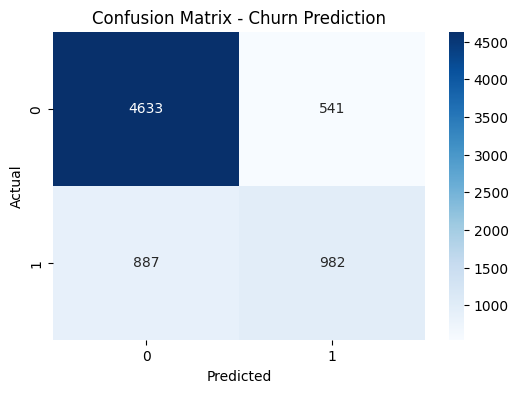

In [21]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Churn Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

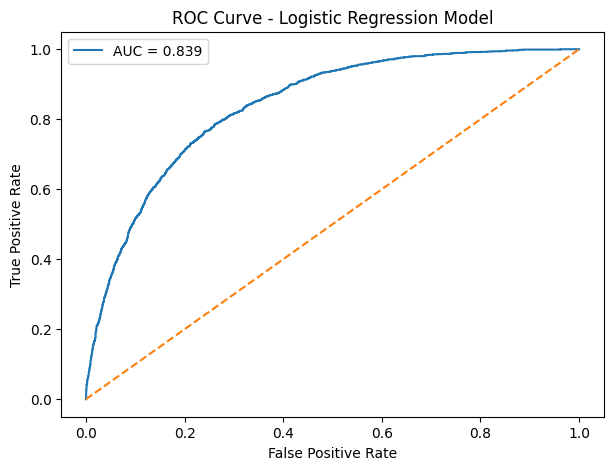

In [22]:
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title("ROC Curve - Logistic Regression Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Model Evaluation Insights

The logistic regression model achieved strong predictive performance with:

- Accuracy ≈ 80%
- AUC Score ≈ 0.84

The ROC curve demonstrates that the model effectively distinguishes churning customers from retained customers.

The confusion matrix shows that the model performs particularly well in identifying non-churn customers, while still capturing a meaningful proportion of churners.

However, the model misses some churning customers (false negatives), suggesting that lowering the classification threshold could improve recall and support more proactive retention strategies.

From a business perspective, the model provides a strong foundation for identifying at-risk customers and supporting targeted retention campaigns.

## Logistic Regression Insights

### Key Drivers Reducing Churn

#### Contract Commitment
Customers subscribed to one-year and two-year contracts were significantly less likely to churn.

This indicates that customer commitment and switching barriers play a major role in retention.

#### Customer Tenure
Long-term customers exhibited lower churn probability.

This suggests that familiarity, habit formation, and customer loyalty strengthen over time.

#### Number of Services
Customers subscribed to multiple services showed lower churn risk.

Highly integrated customers become more dependent on the ecosystem, increasing retention.

#### Dependents
Customers with dependents displayed slightly lower churn behaviour, reflecting greater household stability.


### Key Drivers Increasing Churn

#### Monthly Charges
Higher monthly charges significantly increased churn probability.

This highlights customer price sensitivity and the importance of perceived value.

#### Electronic Check Payment Method
Customers using electronic checks were more likely to churn.

This segment may represent lower-commitment or more flexible customers.

#### Paperless Billing
Customers using paperless billing displayed higher churn probability.

This may reflect lower attachment to the provider and easier switching behaviour.

#### Senior Citizens
Senior citizens showed slightly higher churn likelihood, potentially due to pricing sensitivity or service expectations.


## Model Optimization

### Model Optimization
Several non-significant variables were removed to improve model simplicity and interpretability.

The optimized model maintained similar predictive performance while reducing redundancy and multicollinearity.

Variables such as `TotalCharges` were excluded because they overlapped heavily with:

- tenure
- MonthlyCharges

This produced a cleaner and more interpretable business model.


## High-Value Customer Segmentation

### High-Value Customer Definition
High-value customers were identified using the following characteristics:

- Long tenure
- High number of subscribed services
- High monthly revenue contribution
- Low predicted churn probability

These customers represent the most stable and profitable segment of the customer base.


In [23]:
df['churn_prob'] = result.predict(X)

df['high_value'] = (
    (df['tenure'] > df['tenure'].mean()) &
    (df['num_services'] > df['num_services'].mean()) &
    (df['MonthlyCharges'] > df['MonthlyCharges'].mean()) &
    (df['churn_prob'] < 0.3)
)

In [24]:
df[df['high_value'] == True].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,MultipleLines_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,num_services,churn_prob
count,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000
mean,0.163037,60.298071,93.110019,5648.337741,0.500933,0.705040,0.366521,0.729309,0.373367,0.496577,0.668326,0.350965,0.227754,0.087741,0.112010,5.860610,0.096380
std,0.369514,10.938929,14.244908,1457.776445,0.500155,0.456167,0.482004,0.444455,0.483849,0.500144,0.470961,0.477420,0.419513,0.283006,0.315477,1.145889,0.078996
min,0.000000,33.000000,64.800000,2245.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.006947
25%,0.000000,53.000000,81.350000,4583.875000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.032602
50%,0.000000,63.000000,94.350000,5688.450000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.066851
75%,0.000000,70.000000,105.200000,6762.700000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,7.000000,0.144859
max,1.000000,72.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,0.299786


## High-Value Customer Insights

### Key Characteristics of High-Value Customers

- Average tenure ≈ 60 months
- Average monthly charges ≈ £95
- Average total charges ≈ £5,700
- Average number of services ≈ 6
- Average churn probability ≈ 10%

### Business Interpretation

High-value customers are deeply integrated into the company ecosystem and generate strong long-term revenue.

Their low churn probability suggests that:

- They perceive strong value in the services
- They exhibit high engagement levels
- They face greater switching costs

These customers should be prioritised for:

- Retention programs
- Loyalty initiatives
- Upselling opportunities
- Premium customer support

---

## Strategic Recommendations

### Strategic Recommendations
Based on the analysis, several business strategies can be implemented:

### Retention Strategy

- Encourage long-term contracts
- Develop loyalty rewards for long-tenure customers
- Monitor high-risk customer segments closely

### Pricing Strategy

- Review pricing structures for high-charge customers
- Offer personalized discounts to high-risk customers

### Customer Engagement Strategy

- Promote multi-service bundles
- Increase ecosystem integration to reduce switching behaviour

### High-Value Customer Protection

- Provide premium support for high-value customers
- Implement targeted retention campaigns
- Monitor changes in churn probability over time

---

## Conclusion

### Conclusion
This project demonstrates how predictive analytics and statistical modelling can support customer retention and revenue optimization.

The analysis revealed that churn is primarily influenced by:

- Pricing pressure
- Contract commitment
- Customer engagement
- Service integration

The final logistic regression model successfully identified both high-risk and high-value customer segments, providing actionable business insights for retention and growth strategies.

The project highlights the importance of combining statistical modelling with business interpretation to transform customer data into strategic decision-making tools.
```
